# 1. Line Plots

In [1]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [3]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


In [8]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

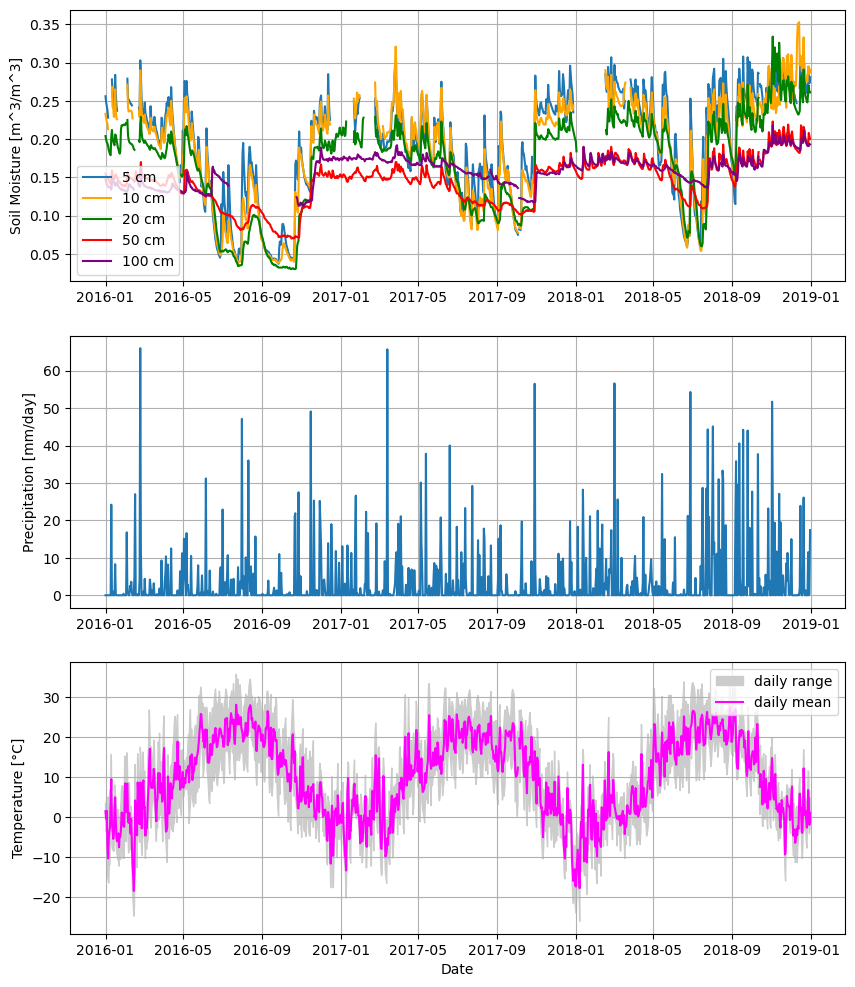

In [70]:
fig,axes = plt.subplots(figsize=(10,12),nrows=3,)
axes[2].grid(True)
axes[1].grid(True)
axes[0].grid(True)

plt.fill_between(date, t_daily_min, t_daily_max, color='0.8', label = "daily range")
axes[2].plot(date, t_daily_mean, color = "magenta", label = "daily mean")
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Temperature [°C]')
axes[2].legend(loc='upper right')
#axes[2].set_xlim(left=0)
#axes[2].set_ylim(bottom=0)

axes[1].plot(date, p_daily_calc)
axes[1].set_ylabel('Precipitation [mm/day]')

axes[0].plot(date, soil_moisture_5, label = "5 cm")
axes[0].plot(date, soil_moisture_10, color = "orange", label = "10 cm")
axes[0].plot(date, soil_moisture_20, color = "green", label = "20 cm")
axes[0].plot(date, soil_moisture_50, color = "red", label = "50 cm")
axes[0].plot(date, soil_moisture_100, color = "purple", label = "100 cm")
axes[0].set_ylabel('Soil Moisture [m^3/m^3]')
axes[0].legend(loc='lower left')




#axes[0].plot(date, t_daily_max, color = "0.8")
#axes[0].fill_between.plot(date, t_daily_min,t_daily_max, color = "0.8")


# 2. Contour Plots

In [72]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

(-88.54196166992188, 88.54196166992188)

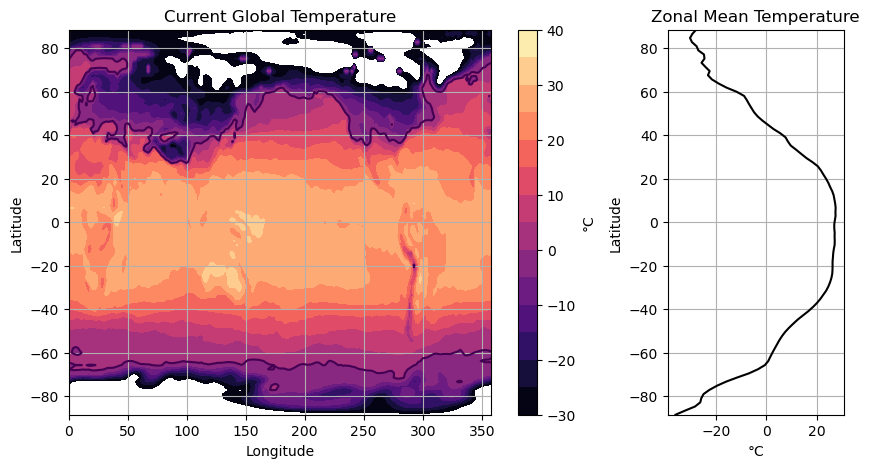

In [97]:
zonal_mean = np.mean(temp, axis=1)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10,5),
    gridspec_kw={'width_ratios':[3,1]}
)

ax1.grid(True)
ax2.grid(True)

levels = np.linspace(-30, 40, 15)

cont = ax1.contourf(lon, lat, temp, levels=levels, cmap="magma")
ax1.contour(lon, lat, temp, levels=[0],)

ax1.set_title("Current Global Temperature")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

cbar = fig.colorbar(cont, ax=ax1)
cbar.set_label("°C")

ax2.plot(zonal_mean, lat, color="black")
ax2.set_title("Zonal Mean Temperature")

ax2.set_xlabel("°C")
ax2.set_ylabel("Latitude")

ax2.set_ylim(lat.min(), lat.max())

# 3. Scatter plots

In [98]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

Unzipping contents of '/home/cam2463/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip' to '/home/cam2463/.cache/pooch/031a30a92d6a3a2680d86514a24e9321-signif.txt.tsv.zip.unzip'


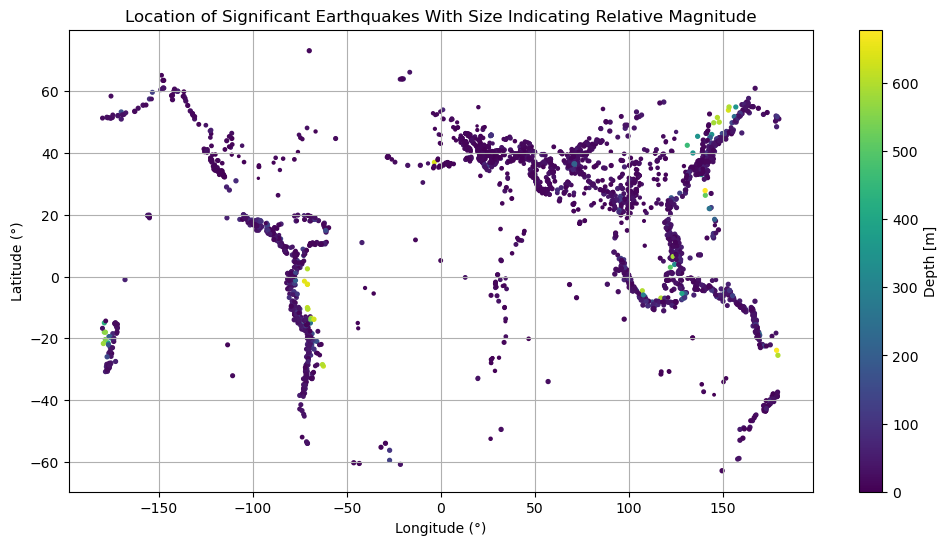

In [108]:

plt.figure(figsize=(12,6))

sc = plt.scatter(
    longitude,
    latitude,
    s=magnitude,
    c=depth,
    cmap="viridis",
    
)

plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.title("Location of Significant Earthquakes With Size Indicating Relative Magnitude")

cbar = plt.colorbar(sc)
cbar.set_label("Depth [m]")

plt.grid(True)